In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import sys
from pathlib import Path

# Add the project root (ml_laboratory) to Python's search path
sys.path.append(str(Path().resolve().parent))
from sklearn.preprocessing import (
StandardScaler, OneHotEncoder
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (
    LinearRegression,
    Ridge, Lasso, ElasticNet
)
from sklearn.metrics import (
mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
)
import time

# Using the EDA functions from assignment 1
from utils import (
    eda_images,eda_tabular
)
print("Imported successfully")

Imported successfully
Imported successfully


Shape: (592, 12)

Column types:
 Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

Missing values:
 Gender               13
Married               2
Dependents           13
Education             0
Self_Employed        31
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

Duplicate rows: 0

Summary statistics:
        ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       592.000000         592.000000  592.000000        578.000000   
mean       5404.304054        1642.633311  146.412162        342.145329   
std        6164.0730

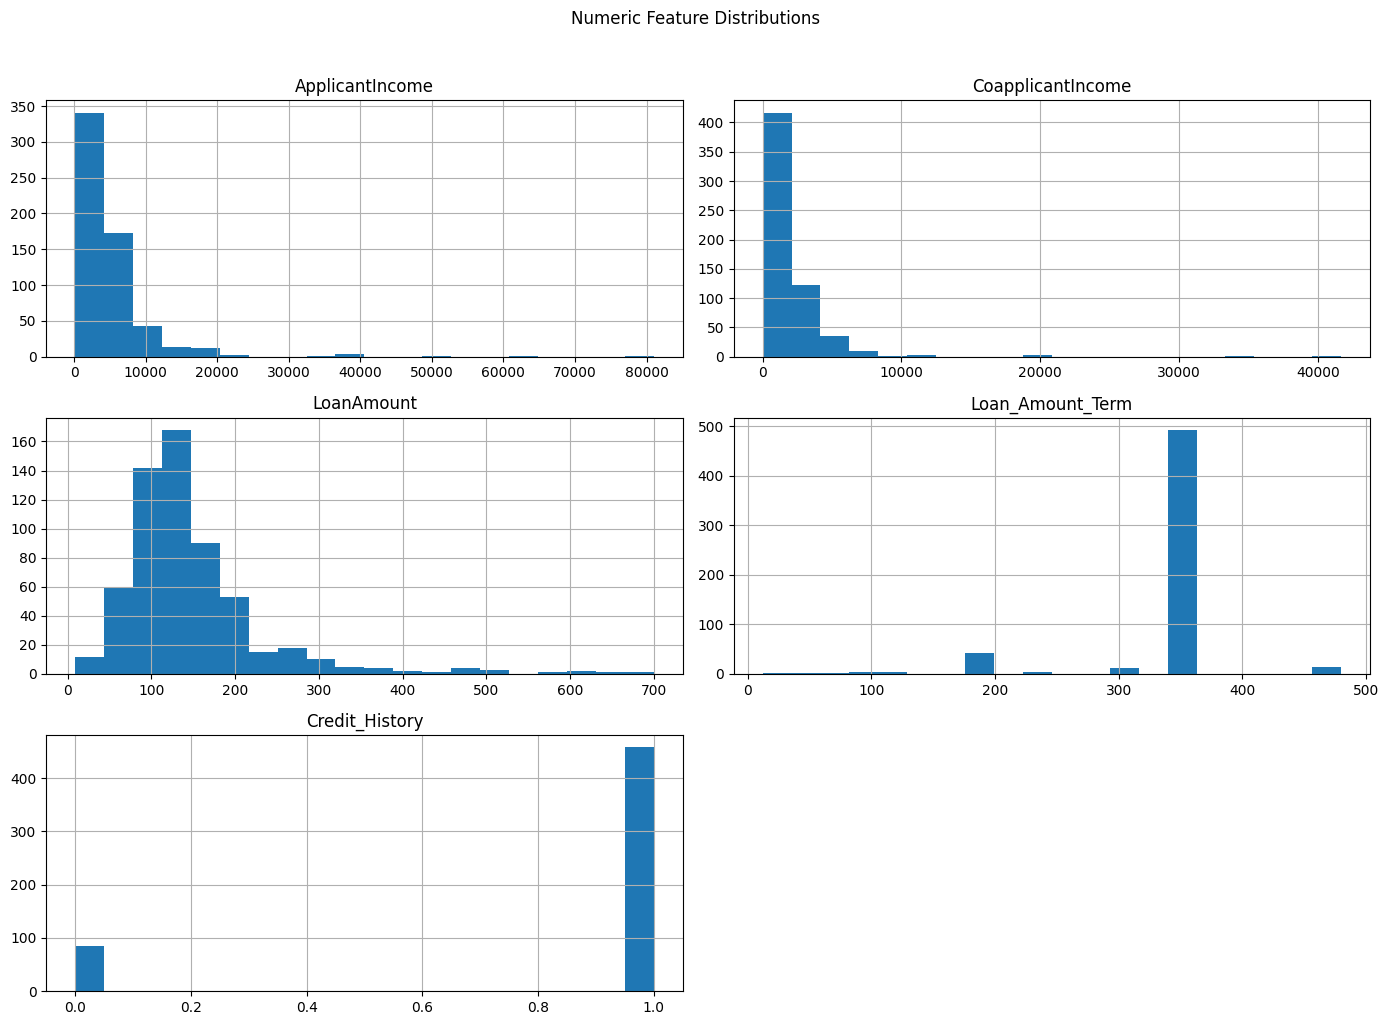

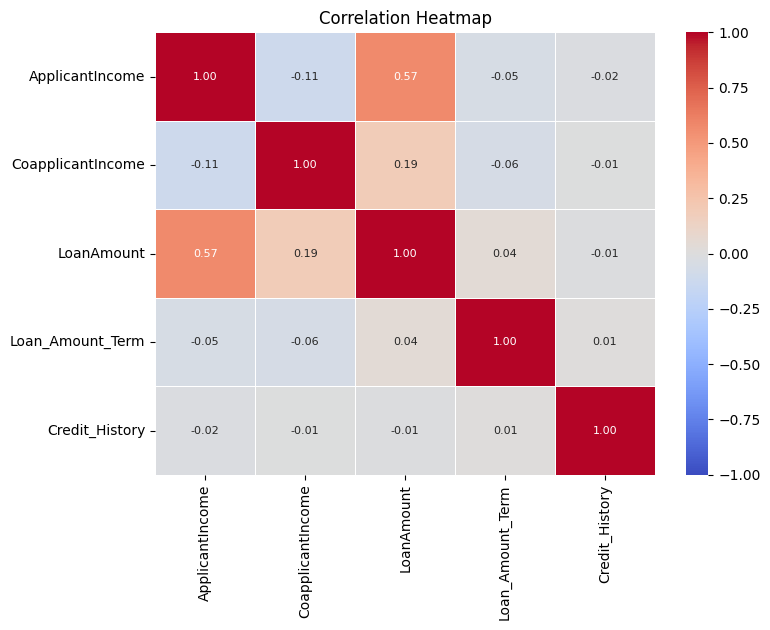


Plotting Categorical Distributions...


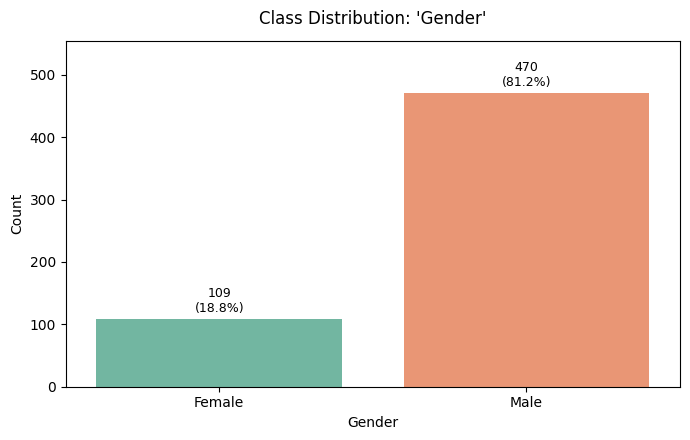

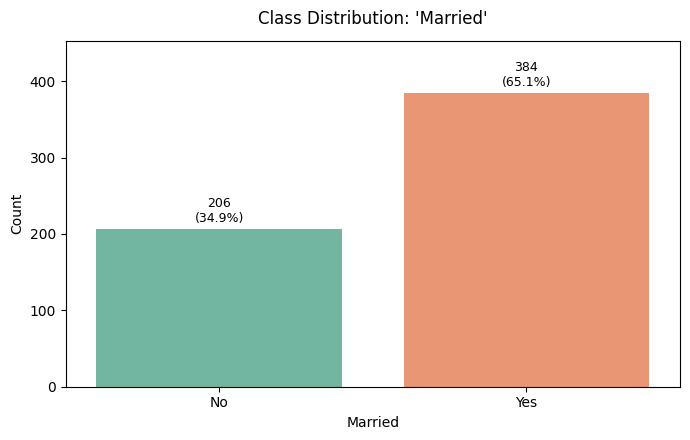

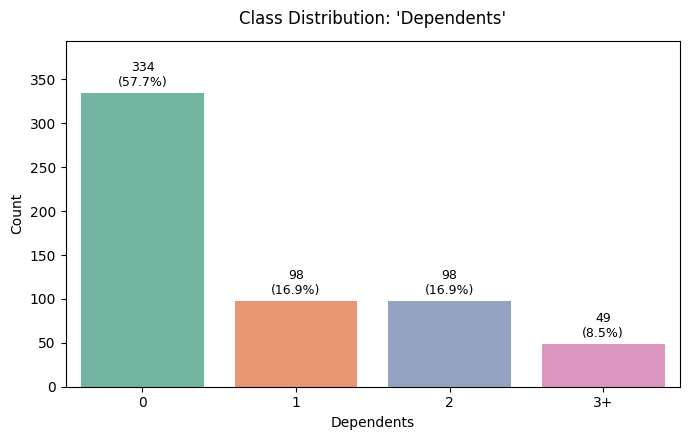

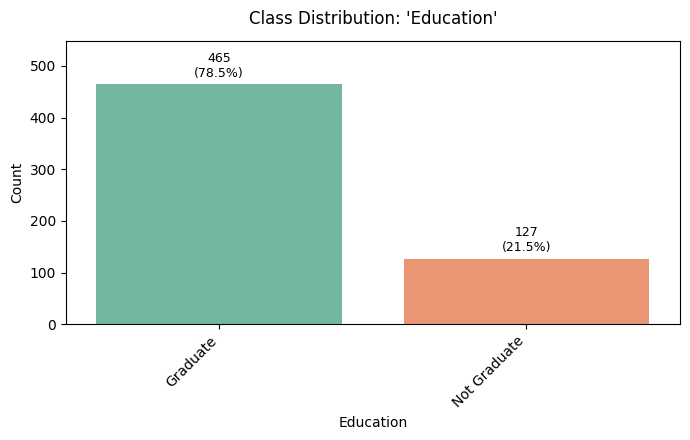

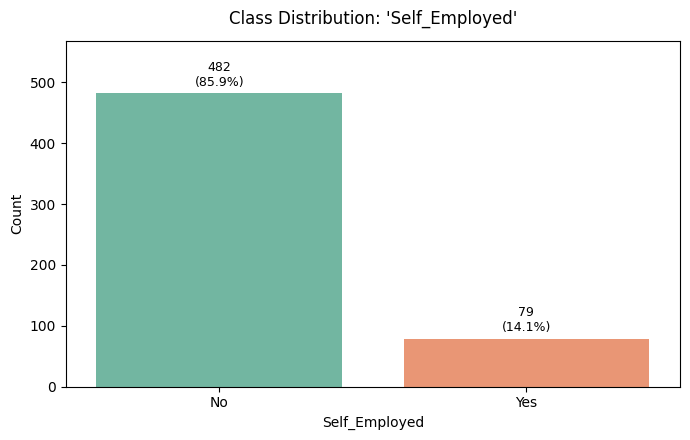

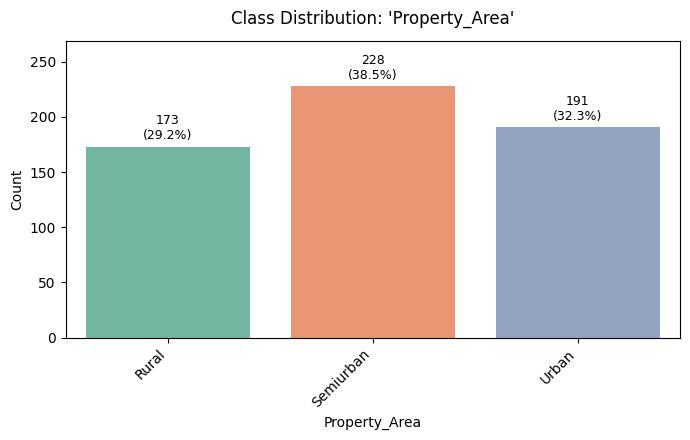

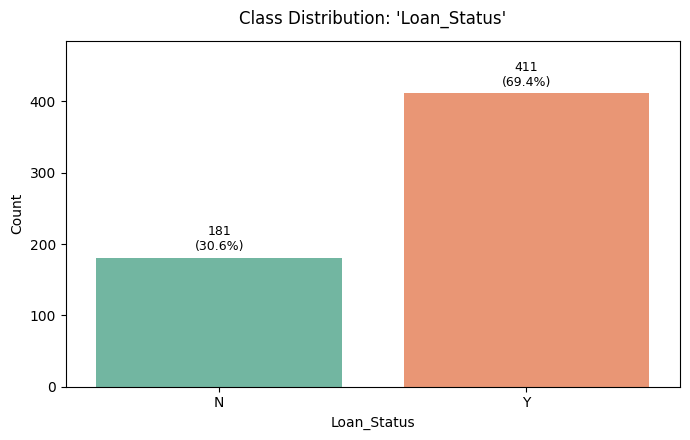

(Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
        'Loan_Amount_Term', 'Credit_History'],
       dtype='str'),
 Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
        'Property_Area', 'Loan_Status'],
       dtype='str'))

In [3]:
df = pd.read_csv("../datasets/loan_prediction/train.csv")
df.drop("Loan_ID",axis = 1,inplace =True)
df = df.dropna(subset=["LoanAmount"])
eda_tabular(df)

In [4]:

X = df.drop(['LoanAmount'], axis = 1)
y = df['LoanAmount']

numerical_cols = X.select_dtypes(include=["int64","float64"]).columns
categorical_cols = X.select_dtypes(include=["object","category","str"]).columns

print("Numerical columns are: ",numerical_cols)
print("Categorical columns are: ",categorical_cols)


Numerical columns are:  Index(['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term',
       'Credit_History'],
      dtype='str')
Categorical columns are:  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='str')


In [5]:
# Missing value handling
numeric_transform = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transform = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [6]:
# Encoding and standardization
preprocessor = ColumnTransformer(
    transformers=[
        ("num",numeric_transform,numerical_cols),
        ("cat",categorical_transform,categorical_cols)
    ]
)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Preprocessing
X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)
print(X_train.shape)
print(X_test.shape)

(473, 21)
(119, 21)


In [8]:
def actual_vs_pred(y_test, y_pred, name = None):
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Loan Amount")
    plt.ylabel("Predicted Loan Amount")
    if name == None:
        plt.title("Actual vs Predicted values")
    else:
        plt.title(f"Actual vs Predicted values of model {name}")
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )

def residual_plot(y_test, y_pred, name = None):
    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, color = 'red', linestyle = '--')
    plt.xlabel("predicted")
    plt.ylabel("Residual")
    if name == None:
        plt.title("Residual Plot")
    else:
        plt.title(f"Residual plot of model {name}")

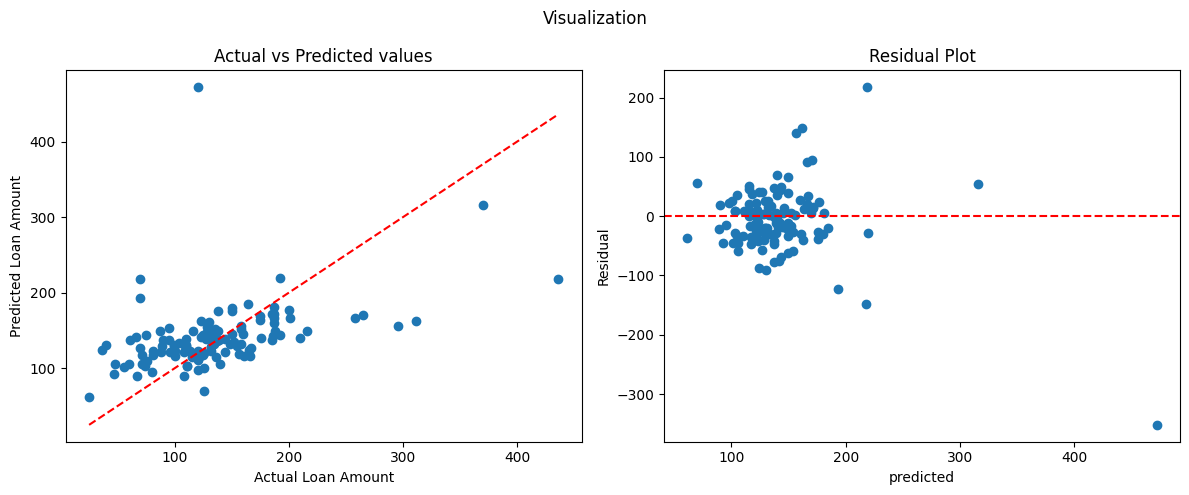

In [10]:
# Now using train and test dataset apply Linear Regression
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet()
}
model = LinearRegression()
model.fit(X_train,y_train)

# Making predictions
y_pred = model.predict(X_test)
plt.figure(figsize = (12,5))
plt.suptitle(f"Visualization")
plt.subplot(1,2,1)
actual_vs_pred(y_test,y_pred)
plt.subplot(1,2,2)
residual_plot(y_test, y_pred)
plt.tight_layout()
plt.show()

# Performance Metrics
|  Regression  |   Classification  |
|--------------|-------------------|
| Mean Absolute Error        |    Accuracy       |
| Mean Squared error          |   Precision     |
| Root mean squared error    |  Recall   |
| $R^2$ error |  f1 score |

Since this is regression model we have to use MAE, MSE, RMSE, R2 error

In [13]:

from sklearn.model_selection import cross_validate

for func in models:
    print(f"\n======= {func} =======")
    models[func].fit(X_train,y_train)
    
    # Making predictions
    y_pred = models[func].predict(X_test)

    # Cross validation

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", models[func])
    ])

    # Define the scoring metrics
    scoring = {
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'mse': 'neg_mean_squared_error',
        'rmse': 'neg_root_mean_squared_error'
    }

    # Run multi-metric cross-validation
    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=5,
        scoring=scoring
    )

    # Extract and convert metrics to positive values
    r2_scores = cv_results['test_r2']
    mae_scores = -cv_results['test_mae']
    mse_scores = -cv_results['test_mse']
    rmse_scores = -cv_results['test_rmse']

    # Print average scores across all 5 folds
    print(f"Mean R2:   {r2_scores.mean():.4f}")
    print(f"Mean MAE:  {mae_scores.mean():.4f}")
    print(f"Mean MSE:  {mse_scores.mean():.4f}")
    print(f"Mean RMSE: {rmse_scores.mean():.4f}")
        


======= Linear Regression =======
Mean R2:   0.2370
Mean MAE:  42.9790
Mean MSE:  5202.6725
Mean RMSE: 70.1696

======= Ridge =======
Mean R2:   0.2383
Mean MAE:  42.9597
Mean MSE:  5195.1869
Mean RMSE: 70.1300

======= Lasso =======
Mean R2:   0.2545
Mean MAE:  42.2666
Mean MSE:  5069.7122
Mean RMSE: 69.4415

======= ElasticNet =======
Mean R2:   0.3001
Mean MAE:  44.5023
Mean MSE:  4993.7565
Mean RMSE: 69.6354


In [ ]:

from sklearn.model_selection import GridSearchCV

models = {
    "Linear Regression": (
        LinearRegression(),
        {}
    ),
    
    "Ridge Regression": (
        Ridge(),
        {
            "alpha":[0.001,0.01,0.1,1,10,100]
        }
    ),
    
    "Lasso Regression": (
        Lasso(),
        {
            "alpha":[0.001,0.01,0.1,1,10,100]
        }
    ),
    
    "ElasticNet "
    "Regression": (
        ElasticNet(max_iter=10000),
        {
            "alpha":[0.001,0.01,0.1,1,10,100],
            "l1_ratio":[0.1,0.3,0.5,0.7,0.9]
        }
    )
}

for name, (model, params) in models.items():

    print(f"\n{name}")

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)

    print("Best Parameters :", grid.best_params_)
    print("Best CV Score   :", grid.best_score_)


Linear Regression
Best Parameters : {}
Best CV Score   : 0.18402531464249766

Ridge Regression


Best Parameters : {'alpha': 100}
Best CV Score   : 0.3406664168081769

Lasso Regression
Best Parameters : {'alpha': 10}
Best CV Score   : 0.2544201600239591

ElasticNet Regression
Best Parameters : {'alpha': 1, 'l1_ratio': 0.7}
Best CV Score   : 0.34077198822391347


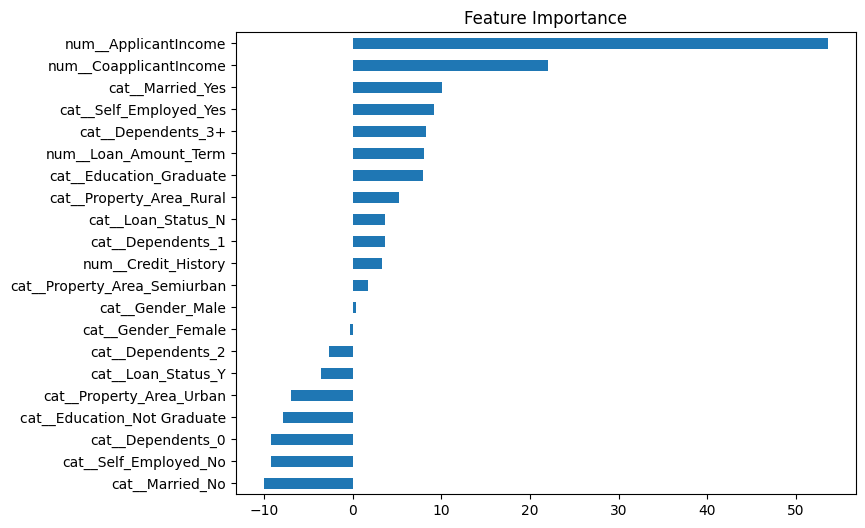

In [33]:
model = Ridge()
model.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()
coef = pd.Series(model.coef_, index=feature_names)

coef.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()